# 16. Cross-Species eRegulon Divergence Analysis

Map SCENIC+ eRegulon region-gene links to the unified cross-species peak IDs, stratify by cell type (posthoc via DAR overlap), then quantify TF enhancer and target gene divergence across 6 primate species.

**Using:** Non-seed SCENIC+ runs (full dataset, one per species).

**Cell type stratification:** For each cell type, an eRegulon region is considered 'active' in that cell type if it overlaps a DAR for that cell type. This splits each global eRegulon into cell-type-specific subsets posthoc.

**Outputs:**
- Per-species eRegulon tables with peak_ids
- Master cross-species table (all species × cell types)
- Per-TF divergence scores (enhancer level and gene level)
- Figures: scatter, heatmaps, bar plots

## 1. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import pyranges as pr
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from pathlib import Path
from itertools import combinations

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 120

In [ ]:
# ── Paths ────────────────────────────────────────────────────────────────────
BASE_ANALYSIS  = Path("/home/jjanssens/jjans/analysis/adult_intestine")
SCPLUS_DIR     = Path("/links/groups/treutlein/USERS/jjans/analysis/adult_intestine/scenicplus")
CONSENSUS_DIR  = Path("/links/groups/treutlein/USERS/jjans/analysis/adult_intestine/peaks/cross_species_consensus_v3")
MASTER_ANNOT   = CONSENSUS_DIR / "07_master_annotation" / "master_annotation_final.tsv"
PEAKSET_DIR    = CONSENSUS_DIR / "10_final"
REGION_SET_DIR = BASE_ANALYSIS / "atac"
OUT_DIR        = CONSENSUS_DIR / "16_scenicplus_eregulon_divergence"
OUT_DIR.mkdir(exist_ok=True)

SPECIES = ["Human", "Gorilla", "Chimpanzee", "Bonobo", "Marmoset", "Macaque"]

COMMON_CELL_TYPES = [
    "BEST4__cells", "Colonocytes", "Crypt_Fibroblasts_WNT2B", "ECs", "EECs",
    "Enteric_glia", "Enterocytes", "Goblet_cells", "Lymphatic_ECs", "Macrophages",
    "Myofibroblasts", "Naive_B_cells", "Paneth_cells", "Pericytes", "Plasma_B_cells",
    "Specialized_Fibroblasts_KCNN3", "Specialized_Fibroblasts_RSPO2_3",
    "Specialized_Fibroblasts_RSPO3__only", "Specialized_Fibroblasts_SYNM",
    "Stem_cells", "TA_cells", "T_cells", "Tuft_cells", "Villus_Fibroblasts_WNT5B",
]

# ── Species colours ───────────────────────────────────────────────────────────
SPECIES_COLORS = {
    'Human':      '#43A047',
    'Chimpanzee': '#FCB216',
    'Bonobo':     '#1A889D',
    'Gorilla':    '#892782',
    'Macaque':    '#EF476F',
    'Marmoset':   '#F36F21',
}

# ── Cell-type colours ────────────────────────────────────────────────────────
CELL_TYPE_COLORS = {
    'Enterocytes': '#D95B27', 'Colonocytes': '#DA5C2D', 'TA cells': '#F5865F',
    'BEST4 cells': '#913C1F', 'BEST4+ cells': '#913C1F',
    'Fibroblasts SYNM+': '#E59825', 'Fibroblasts RSPO2/3+': '#FCB137',
    'Myofibroblasts': '#AA732A', 'Fibroblasts PCDH9+': '#A8762B',
    'Fibroblasts RALYL+': '#8C411E', 'Fibroblasts RSPO3+': '#FECC81',
    'Crypt Fibroblasts WNT2B+': '#AB7B2C', 'Enteric glia': '#F05653',
    'Fibroblasts ADAMTS16+': '#533B16', 'Villus Fibroblasts WNT5B+': '#FDC172',
    'Fibroblasts VCAM1+': '#F7AF1A', 'Fibroblasts KCNN3+': '#F4C068',
    'ICCs': '#DA9C28', 'Goblet cells': '#A14223', 'Paneth cells': '#F7956F',
    'Stem cells': '#F6967B', 'Tuft cells': '#F8A488', 'Enteric neurons': '#93292A',
    'Pericytes': '#FECE92', 'Mast cells': '#872890', 'Mesothelial cells': '#FDD7A4',
    'ECs': '#327338', 'NK/ILCs': '#822989', 'Eosinophils': '#B975B1',
    'Neutrophils': '#852990', 'T cells': '#CD7AB2', 'Lymphatic ECs': '#64BB67',
    'RBP2 high cells': '#8E191D', 'MARCO+ Lymphatic ECs': '#238842',
    'Adipocytes': '#895422', 'Naive B Cells': '#A9459A', 'Naive B cells': '#A9459A',
    'MUC6+ cells': '#D1643D', 'EECs': '#B25A27',
    'Macrophages': '#822989', 'Monocytes': '#9B59B6', 'Plasma B cells': '#8E44AD',
}

BROAD_CLASS_COLORS = {
    'Epithelial': '#D24627', 'Immune': '#A54A9C',
    'Neuronal': '#D42027', 'Endothelial': '#377639', 'Mesenchymal': '#D69E28',
}

CELL_TYPE_MAP = {
    'BEST4+ cells': 'Epithelial', 'BEST4 cells': 'Epithelial',
    'Colonocytes': 'Epithelial', 'EECs': 'Epithelial',
    'Enterocytes': 'Epithelial', 'Goblet cells': 'Epithelial',
    'MUC6+ cells': 'Epithelial', 'Paneth cells': 'Epithelial',
    'RBP2 high cells': 'Epithelial', 'Stem cells': 'Epithelial',
    'TA cells': 'Epithelial', 'Tuft cells': 'Epithelial',
    'Adipocytes': 'Mesenchymal', 'Crypt Fibroblasts WNT2B+': 'Mesenchymal',
    'Fibroblasts ADAMTS16+': 'Mesenchymal', 'Fibroblasts KCNN3+': 'Mesenchymal',
    'Fibroblasts PCDH9+': 'Mesenchymal', 'Fibroblasts RALYL+': 'Mesenchymal',
    'Fibroblasts RSPO2/3+': 'Mesenchymal', 'Fibroblasts RSPO3+': 'Mesenchymal',
    'Fibroblasts SYNM+': 'Mesenchymal', 'Fibroblasts VCAM1+': 'Mesenchymal',
    'ICCs': 'Mesenchymal', 'Mesothelial cells': 'Mesenchymal',
    'Myofibroblasts': 'Mesenchymal', 'Pericytes': 'Mesenchymal',
    'Villus Fibroblasts WNT5B+': 'Mesenchymal',
    'Eosinophils': 'Immune', 'Macrophages': 'Immune', 'Mast cells': 'Immune',
    'Monocytes': 'Immune', 'Naive B Cells': 'Immune', 'Naive B cells': 'Immune',
    'Neutrophils': 'Immune', 'NK/ILCs': 'Immune',
    'Plasma B cells': 'Immune', 'T cells': 'Immune',
    'ECs': 'Endothelial', 'Lymphatic ECs': 'Endothelial',
    'MARCO+ Lymphatic ECs': 'Endothelial',
    'Enteric glia': 'Neuronal', 'Enteric neurons': 'Neuronal',
}

def _make_ct_lookup(color_dict):
    lookup = dict(color_dict)
    for name, color in color_dict.items():
        lookup.setdefault(name.replace(" ", "_").replace("+", "p"), color)
    return lookup

CT_COLOR_LOOKUP = _make_ct_lookup(CELL_TYPE_COLORS)
REGION_COLORS = {'Duodenum': '#009481', 'Colon': '#C33956'}

print(f"Species: {SPECIES}")
print(f"Common cell types: {len(COMMON_CELL_TYPES)}")
print(f"Output dir: {OUT_DIR}")

## 2. Helper functions

In [7]:
def eregulon_to_pyranges(df, region_col="Region"):
    """Convert eRegulon DataFrame with 'chr:start-end' regions to PyRanges."""
    parsed = df[region_col].str.extract(r"^(.+?):(\d+)-(\d+)$")
    parsed.columns = ["Chromosome", "Start", "End"]
    parsed["Start"] = parsed["Start"].astype(int)
    parsed["End"]   = parsed["End"].astype(int)
    parsed[region_col] = df[region_col].values
    return pr.PyRanges(parsed.dropna(subset=["Chromosome"]))


def bed_to_pyranges(bed_path):
    """Load a BED4 file (chr, start, end, name) as PyRanges."""
    df = pd.read_csv(bed_path, sep="\t", header=None,
                     names=["Chromosome", "Start", "End", "peak_id"],
                     usecols=[0, 1, 2, 3])
    return pr.PyRanges(df)


def bed3_to_pyranges(bed_path):
    """Load any BED file as PyRanges, using only the first 3 columns."""
    df = pd.read_csv(bed_path, sep="\t", header=None, usecols=[0, 1, 2])
    df.columns = ["Chromosome", "Start", "End"]
    return pr.PyRanges(df)


def map_regions_to_peak_ids(regions_pr, peakset_pr):
    """
    Join eRegulon regions to the final peakset on overlap.
    Returns dict: region_str -> peak_id  (first overlapping peak wins).
    """
    joined = regions_pr.join(peakset_pr, how="left", suffix="_peak")
    df = joined.df[["Region", "peak_id"]].dropna()
    df = df[df["peak_id"] != -1]  # pyranges 0.0.x uses -1 for unmatched
    return df.drop_duplicates("Region").set_index("Region")["peak_id"].to_dict()


def filter_to_cell_type_DARs(ereg_df, dar_pr, region_col="Region"):
    """
    Return subset of ereg_df whose regions overlap DAR PyRanges for a cell type.
    """
    unique_regions = ereg_df[[region_col]].drop_duplicates()
    reg_pr = eregulon_to_pyranges(unique_regions, region_col=region_col)
    if len(reg_pr) == 0:
        return ereg_df.iloc[:0]
    hits = reg_pr.overlap(dar_pr)
    if len(hits) == 0:
        return ereg_df.iloc[:0]
    active_regions = set(hits.df[region_col])
    return ereg_df[ereg_df[region_col].isin(active_regions)].copy()


print("Helper functions loaded.")

Helper functions loaded.


## 3. Load eRegulons and map to peak_ids

For each species, load `eRegulons_extended.tsv` and map the regions to `peak_id` from the final peakset.

In [4]:
# Load peaksets as PyRanges (done once per species)
peakset_pr = {}
for sp in SPECIES:
    path = PEAKSET_DIR / f"all_peaks_{sp}.bed"
    peakset_pr[sp] = bed_to_pyranges(path)
    print(f"{sp}: {len(peakset_pr[sp]):,} peaks")

Human: 1,039,336 peaks
Gorilla: 1,013,198 peaks
Chimpanzee: 1,029,053 peaks
Bonobo: 992,889 peaks
Marmoset: 971,722 peaks
Macaque: 982,905 peaks


In [5]:
eregulon_raw = {}   # species -> full eRegulons DataFrame (with peak_id)
eregulon_pr  = {}   # species -> PyRanges of unique regions (for DAR filtering)

for sp in SPECIES:
    path = SCPLUS_DIR / f"scplus_pipeline_{sp}" / "Snakemake" / "eRegulons_extended.tsv"
    if not path.exists():
        print(f"{sp}: NOT FOUND, skipping")
        continue
    
    df = pd.read_csv(path, sep="\t")
    print(f"{sp}: {len(df):,} triplets, {df['Region'].nunique():,} unique regions, "
          f"{df['TF'].nunique()} TFs, {df['Gene'].nunique():,} genes")
    
    # Map regions to peak_ids
    unique_reg_df = df[["Region"]].drop_duplicates()
    reg_pr = eregulon_to_pyranges(unique_reg_df)
    region_to_peak = map_regions_to_peak_ids(reg_pr, peakset_pr[sp])
    
    df["peak_id"] = df["Region"].map(region_to_peak)
    n_mapped = df["peak_id"].notna().sum()
    print(f"  -> {n_mapped:,}/{len(df):,} triplets mapped ({100*n_mapped/len(df):.1f}%)")
    
    df["species"] = sp
    eregulon_raw[sp] = df
    eregulon_pr[sp]  = reg_pr  # used below for DAR filtering

# Save per-species tables
for sp, df in eregulon_raw.items():
    out = OUT_DIR / f"{sp}_eRegulons_with_peak_ids.tsv"
    df.to_csv(out, sep="\t", index=False)
print("Per-species tables saved.")

Human: 115,140 triplets, 51,892 unique regions, 156 TFs, 8,681 genes
  -> 115,140/115,140 triplets mapped (100.0%)
Gorilla: 101,829 triplets, 49,286 unique regions, 99 TFs, 9,417 genes
  -> 101,829/101,829 triplets mapped (100.0%)
Chimpanzee: 98,957 triplets, 45,870 unique regions, 100 TFs, 9,830 genes
  -> 98,957/98,957 triplets mapped (100.0%)
Bonobo: 91,484 triplets, 40,092 unique regions, 71 TFs, 9,081 genes
  -> 91,484/91,484 triplets mapped (100.0%)
Marmoset: 76,626 triplets, 41,946 unique regions, 81 TFs, 8,079 genes
  -> 76,626/76,626 triplets mapped (100.0%)
Macaque: 64,889 triplets, 30,977 unique regions, 77 TFs, 8,342 genes
  -> 64,889/64,889 triplets mapped (100.0%)
Per-species tables saved.


## 4. Cell-type stratification (posthoc DAR filter)

For each (species, cell type), keep only eRegulon regions that overlap the cell type's DAR BED file.
This gives a cell-type-specific slice of each TF's eRegulon without re-running SCENIC+.

In [8]:
# Build: for each species, a dict of cell_type -> DAR PyRanges
dar_pr = {}  # dar_pr[species][cell_type] = PyRanges

for sp in SPECIES:
    dar_dir = REGION_SET_DIR / f"region_sets_{sp}" / "DARs_cell_type"
    dar_pr[sp] = {}
    for ct in COMMON_CELL_TYPES:
        bed = dar_dir / f"{ct}.bed"
        if bed.exists():
            dar_pr[sp][ct] = bed3_to_pyranges(bed)
        else:
            print(f"  MISSING: {sp} / {ct}")

# Quick sanity check: how many DARs per cell type for Human?
print("\nHuman DAR counts (sample):")
for ct in list(COMMON_CELL_TYPES)[:5]:
    n = len(dar_pr.get('Human', {}).get(ct, pr.PyRanges()))
    print(f"  {ct}: {n:,} DARs")


Human DAR counts (sample):
  BEST4__cells: 14,545 DARs
  Colonocytes: 18,521 DARs
  Crypt_Fibroblasts_WNT2B: 15,981 DARs
  ECs: 9,534 DARs
  EECs: 6,238 DARs


In [9]:
# Apply DAR filter to produce per-(species, cell_type) eRegulon slices
# Result: list of dicts -> will become a long-format DataFrame

records = []  # will hold all rows for combined analysis

for sp in SPECIES:
    if sp not in eregulon_raw:
        continue
    full_df = eregulon_raw[sp]
    
    for ct in COMMON_CELL_TYPES:
        dpr = dar_pr.get(sp, {}).get(ct)
        if dpr is None or len(dpr) == 0:
            continue
        
        ct_df = filter_to_cell_type_DARs(full_df, dpr)
        if len(ct_df) == 0:
            continue
        ct_df = ct_df[ct_df["peak_id"].notna()].copy()
        ct_df["cell_type"] = ct
        records.append(ct_df)

combined = pd.concat(records, ignore_index=True)
print(f"Combined cell-type-stratified table: {len(combined):,} rows")
print(f"  Species × cell type combinations: {combined.groupby(['species','cell_type']).ngroups}")
print(f"  Unique TFs: {combined['TF'].nunique()}")
print(f"  Unique peak_ids: {combined['peak_id'].nunique():,}")

Combined cell-type-stratified table: 1,586,762 rows
  Species × cell type combinations: 144
  Unique TFs: 229
  Unique peak_ids: 35,370


## 5. Join with master annotation

Add cross-species orthology information from the consensus peakset master annotation.

In [10]:
master = pd.read_csv(MASTER_ANNOT, sep="\t", low_memory=False)
print(f"Master annotation: {len(master):,} peaks")

det_cols  = [c for c in master.columns if c.endswith("_det")]
orth_cols = [c for c in master.columns if c.endswith("_orth")]

print("Detection columns:",  det_cols)
print("Orthology columns:", orth_cols)

Master annotation: 1,142,003 peaks
Detection columns: ['n_species_det', 'Human_det', 'Bonobo_det', 'Chimpanzee_det', 'Gorilla_det', 'Macaque_det', 'Marmoset_det']
Orthology columns: ['n_species_orth', 'Human_orth', 'Bonobo_orth', 'Chimpanzee_orth', 'Gorilla_orth', 'Macaque_orth', 'Marmoset_orth']


In [11]:
master_sub = master[["peak_id", "peak_type", "n_species_det", "n_species_orth"] + det_cols + orth_cols].copy()

combined_annot = combined.merge(master_sub, on="peak_id", how="left")
print(f"After master annotation join: {len(combined_annot):,} rows")
print(f"Unmatched (no master entry): {combined_annot['peak_type'].isna().sum():,}")

# Save full annotated table (large - save parquet if possible, else tsv)
out = OUT_DIR / "all_species_celltype_eRegulons_annotated.parquet"
try:
    combined_annot.to_parquet(out, index=False)
    print(f"Saved parquet: {out}")
except Exception:
    out = OUT_DIR / "all_species_celltype_eRegulons_annotated.tsv"
    combined_annot.to_csv(out, sep="\t", index=False)
    print(f"Saved tsv: {out}")

After master annotation join: 1,586,762 rows
Unmatched (no master entry): 1,180,132
Saved tsv: /links/groups/treutlein/USERS/jjans/analysis/adult_intestine/peaks/cross_species_consensus_v3/16_scenicplus_eregulon_divergence/all_species_celltype_eRegulons_annotated.tsv


## 6. Divergence metrics per (TF, cell type)

For each (TF, cell type) pair, compute:
1. **Enhancer conservation**: fraction of eRegulon peaks with ortholog in each species
2. **Target gene conservation**: pairwise Jaccard of gene sets across species

In [12]:
# Map column names to species labels
det_sp  = {c.replace("_det",  ""): c for c in det_cols}
orth_sp = {c.replace("_orth", ""): c for c in orth_cols}

# Index master by peak_id for fast orthology lookups
master_idx = master_sub.set_index("peak_id")

In [13]:
# ── 6A: Enhancer conservation ─────────────────────────────────────────────────
# For each (TF, cell_type, source_species): get peak_ids → look up orthology across species

tf_peaks = (
    combined_annot
    .groupby(["TF", "cell_type", "species"])["peak_id"]
    .apply(set)
    .reset_index()
    .rename(columns={"peak_id": "peak_ids"})
)

enh_rows = []
for _, row in tf_peaks.iterrows():
    peak_ids = row["peak_ids"]
    hits = master_idx.reindex(peak_ids)
    rec = {"TF": row["TF"], "cell_type": row["cell_type"],
           "source_species": row["species"], "n_peaks": len(peak_ids)}
    for sp in SPECIES:
        c = orth_sp.get(sp)
        rec[f"frac_orth_{sp}"] = hits[c].fillna(0).mean() if c and c in hits.columns else np.nan
    enh_rows.append(rec)

enh_df = pd.DataFrame(enh_rows)
print(f"Enhancer conservation table: {len(enh_df):,} (TF, cell_type, source_species) rows")

Enhancer conservation table: 12,124 (TF, cell_type, source_species) rows


In [14]:
# Aggregate across source species: mean orthology fraction per (TF, cell_type)
frac_cols = [f"frac_orth_{sp}" for sp in SPECIES]

enh_summary = (
    enh_df
    .groupby(["TF", "cell_type"])
    .agg(n_species_source=("source_species", "nunique"),
         total_peaks=("n_peaks", "sum"),
         **{c: (c, "mean") for c in frac_cols})
    .reset_index()
)

enh_summary["orth_mean"]  = enh_summary[frac_cols].mean(axis=1)
enh_summary["orth_std"]   = enh_summary[frac_cols].std(axis=1)
enh_summary["orth_range"] = enh_summary[frac_cols].max(axis=1) - enh_summary[frac_cols].min(axis=1)

print(f"Enhancer summary: {len(enh_summary):,} (TF, cell_type) rows")
enh_summary.sort_values("orth_std", ascending=False).head(5)

Enhancer summary: 4,810 (TF, cell_type) rows


,TF,cell_type,n_species_source,total_peaks,frac_orth_Human,frac_orth_Gorilla,frac_orth_Chimpanzee,frac_orth_Bonobo,frac_orth_Marmoset,frac_orth_Macaque,orth_mean,orth_std,orth_range
4756,ZNF518A,Plasma_B_cells,1,1,1.0,0.0,1.0,1.0,1.0,0.0,0.666667,0.516398,1.0
1002,ETV1,Myofibroblasts,1,1,1.0,0.0,1.0,0.0,1.0,1.0,0.666667,0.516398,1.0
1004,ETV1,Pericytes,1,1,1.0,0.0,1.0,0.0,1.0,1.0,0.666667,0.516398,1.0
647,E2F7,Lymphatic_ECs,1,1,1.0,0.0,1.0,0.0,1.0,1.0,0.666667,0.516398,1.0
1003,ETV1,Paneth_cells,1,1,1.0,0.0,1.0,0.0,1.0,1.0,0.666667,0.516398,1.0


In [15]:
# ── 6B: Target gene conservation ──────────────────────────────────────────────
def jaccard(a, b):
    if not a or not b:
        return np.nan
    return len(a & b) / len(a | b)

tf_genes = (
    combined_annot
    .groupby(["TF", "cell_type", "species"])["Gene"]
    .apply(set)
    .reset_index()
    .rename(columns={"Gene": "gene_set"})
)

gene_rows = []
for (tf, ct), grp in tf_genes.groupby(["TF", "cell_type"]):
    sp_genes = dict(zip(grp["species"], grp["gene_set"]))
    sp_present = list(sp_genes.keys())
    all_genes = set().union(*sp_genes.values())
    
    jaccards = [jaccard(sp_genes[s1], sp_genes[s2])
                for s1, s2 in combinations(sp_present, 2)]
    
    rec = {"TF": tf, "cell_type": ct,
           "n_species_w_eregulon": len(sp_present),
           "n_total_genes": len(all_genes),
           "mean_pairwise_jaccard": np.nanmean(jaccards) if jaccards else np.nan,
           "min_pairwise_jaccard":  np.nanmin(jaccards)  if jaccards else np.nan}
    for sp in SPECIES:
        rec[f"n_genes_{sp}"] = len(sp_genes.get(sp, set()))
    gene_rows.append(rec)

gene_df = pd.DataFrame(gene_rows)
print(f"Gene conservation table: {len(gene_df):,} (TF, cell_type) rows")

Gene conservation table: 4,810 (TF, cell_type) rows


In [16]:
# Merge and filter
tf_div = enh_summary.merge(gene_df, on=["TF", "cell_type"], how="inner")

# Require: present in ≥3 species and ≥5 peaks (per cell type)
tf_div_filt = tf_div[
    (tf_div["n_species_source"]    >= 3) &
    (tf_div["total_peaks"]          >= 5) &
    (tf_div["n_species_w_eregulon"] >= 3)
].copy()

print(f"(TF, cell_type) pairs after filtering: {len(tf_div_filt):,} (from {len(tf_div):,})")
print(f"Unique TFs: {tf_div_filt['TF'].nunique()}, cell types: {tf_div_filt['cell_type'].nunique()}")

out = OUT_DIR / "TF_celltype_divergence_summary.tsv"
tf_div.to_csv(out, sep="\t", index=False)
print(f"Saved: {out}")

(TF, cell_type) pairs after filtering: 1,739 (from 4,810)
Unique TFs: 89, cell types: 24
Saved: /links/groups/treutlein/USERS/jjans/analysis/adult_intestine/peaks/cross_species_consensus_v3/16_scenicplus_eregulon_divergence/TF_celltype_divergence_summary.tsv


## 7. Summary collapsed across cell types

Collapse to per-TF metrics by averaging across cell types (weighted by peak count).

In [17]:
# Weighted average across cell types, weight = total_peaks
def wavg(grp, col, w="total_peaks"):
    weights = grp[w]
    return (grp[col] * weights).sum() / weights.sum() if weights.sum() > 0 else np.nan

tf_global = tf_div_filt.groupby("TF").apply(
    lambda g: pd.Series({
        "n_cell_types": g["cell_type"].nunique(),
        "total_peaks": g["total_peaks"].sum(),
        "orth_std_mean":  wavg(g, "orth_std"),
        "orth_mean_mean": wavg(g, "orth_mean"),
        "gene_jaccard_mean": wavg(g, "mean_pairwise_jaccard"),
        **{f"frac_orth_{sp}": wavg(g, f"frac_orth_{sp}") for sp in SPECIES if f"frac_orth_{sp}" in g.columns},
    })
).reset_index()

print(f"Global TF summary: {len(tf_global)} TFs")
tf_global.sort_values("orth_std_mean", ascending=False).head(10)[[
    "TF", "n_cell_types", "total_peaks", "orth_mean_mean", "orth_std_mean", "gene_jaccard_mean"
]]

Global TF summary: 89 TFs


,TF,n_cell_types,total_peaks,orth_mean_mean,orth_std_mean,gene_jaccard_mean
77,SREBF2,1.0,25.0,0.301932,0.050552,0.046659
62,PLAGL1,21.0,1821.0,0.616552,0.048523,0.010151
68,REST,1.0,5.0,0.314815,0.045361,0.000000
26,GATA2,2.0,10.0,0.314815,0.045361,0.000000
52,NFATC2,24.0,617.0,0.347438,0.041947,0.052861
37,IRF2,2.0,11.0,0.317340,0.039175,0.000000
5,CHD2,23.0,1033.0,0.468401,0.038590,0.007564
71,RFX6,22.0,392.0,0.466763,0.031137,0.037900
46,MEF2A,24.0,676.0,0.382834,0.028936,0.015277
23,FOXP1,24.0,2023.0,0.634893,0.028416,0.009503


In [18]:
out = OUT_DIR / "TF_global_divergence_summary.tsv"
tf_global.to_csv(out, sep="\t", index=False)
print(f"Saved: {out}")

Saved: /links/groups/treutlein/USERS/jjans/analysis/adult_intestine/peaks/cross_species_consensus_v3/16_scenicplus_eregulon_divergence/TF_global_divergence_summary.tsv


## 8. Figures

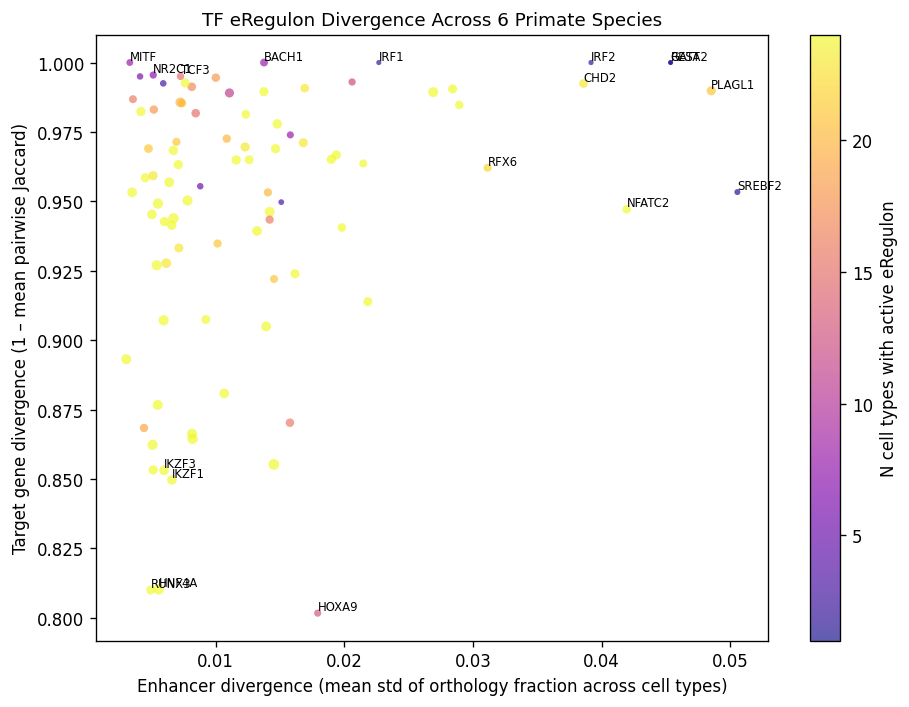

In [19]:
# ── Fig 1: Scatter – enhancer divergence vs gene divergence (global, per TF) ──
fig, ax = plt.subplots(figsize=(8, 6))

x = tf_global["orth_std_mean"]
y = 1 - tf_global["gene_jaccard_mean"]
sz = np.log1p(tf_global["total_peaks"]) * 4
c  = tf_global["n_cell_types"]

sc = ax.scatter(x, y, s=sz, c=c, cmap="viridis", alpha=0.65, edgecolors="none")
plt.colorbar(sc, ax=ax, label="N cell types with active eRegulon")

# Label extremes
to_label = set(
    tf_global.nlargest(8, "orth_std_mean")["TF"].tolist() +
    tf_global.nsmallest(8, "gene_jaccard_mean")["TF"].tolist() +
    tf_global.nlargest(5, "gene_jaccard_mean")["TF"].tolist()
)
for _, r in tf_global[tf_global["TF"].isin(to_label)].iterrows():
    ax.text(r["orth_std_mean"], 1 - r["gene_jaccard_mean"], r["TF"],
            fontsize=7, ha="left", va="bottom")

ax.set_xlabel("Enhancer divergence (mean std of orthology fraction across cell types)", fontsize=10)
ax.set_ylabel("Target gene divergence (1 – mean pairwise Jaccard)", fontsize=10)
ax.set_title("TF eRegulon Divergence Across 6 Primate Species", fontsize=11)
plt.tight_layout()
plt.savefig(OUT_DIR / "Fig1_TF_enh_vs_gene_divergence.pdf", bbox_inches="tight")
plt.savefig(OUT_DIR / "Fig1_TF_enh_vs_gene_divergence.png", dpi=150, bbox_inches="tight")
plt.show()

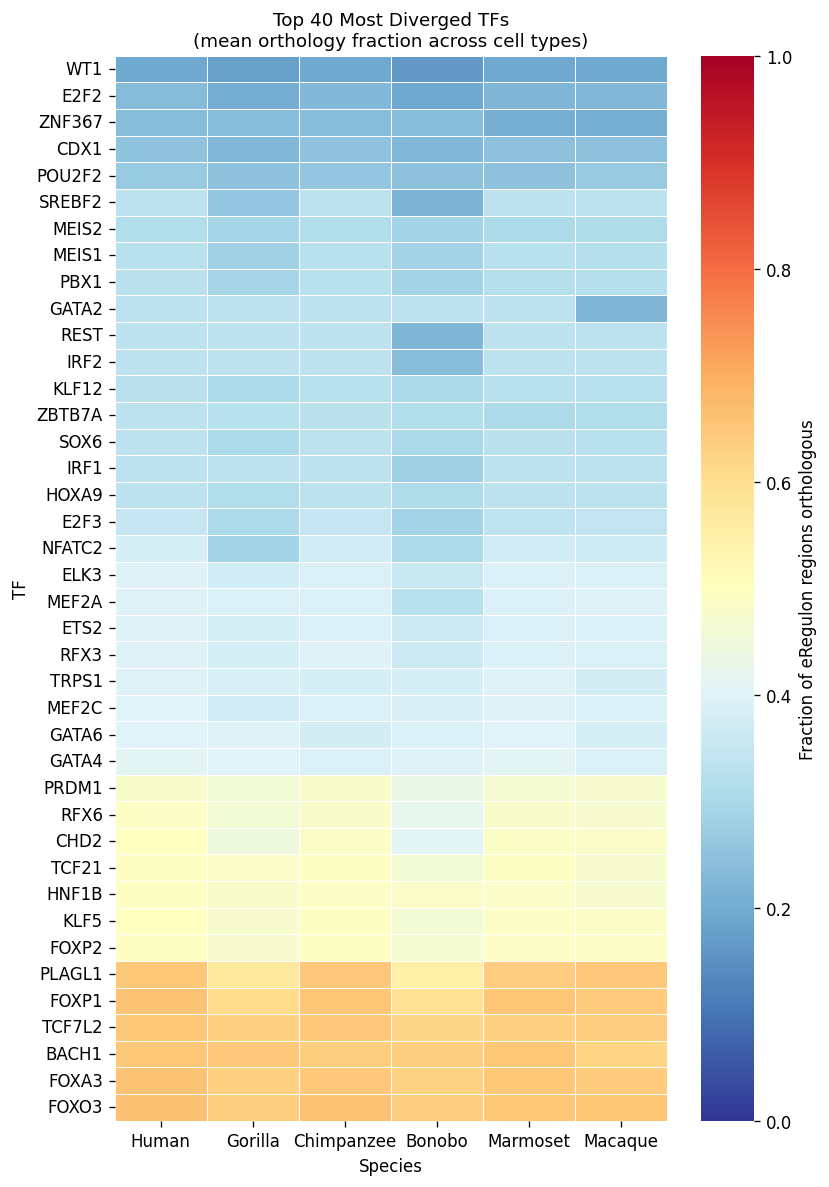

In [20]:
# ── Fig 2: Heatmap – per-species orthology fraction (top 40 most variable TFs) ──
frac_orth_cols = [f"frac_orth_{sp}" for sp in SPECIES if f"frac_orth_{sp}" in tf_global.columns]

top40_var = tf_global.nlargest(40, "orth_std_mean").set_index("TF")
heat = top40_var[frac_orth_cols].rename(columns=lambda c: c.replace("frac_orth_", ""))
heat = heat.loc[heat.mean(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(7, 10))
sns.heatmap(heat, cmap="RdYlBu_r", vmin=0, vmax=1, linewidths=0.3,
            linecolor="white", cbar_kws={"label": "Fraction of eRegulon regions orthologous"},
            ax=ax)
ax.set_title("Top 40 Most Diverged TFs\n(mean orthology fraction across cell types)", fontsize=11)
ax.set_xlabel("Species")
ax.set_ylabel("TF")
# Color species column labels
for lbl in ax.get_xticklabels():
    lbl.set_color(SPECIES_COLORS.get(lbl.get_text(), "black"))
plt.tight_layout()
plt.savefig(OUT_DIR / "Fig2_heatmap_top40_variable_TFs.pdf", bbox_inches="tight")
plt.savefig(OUT_DIR / "Fig2_heatmap_top40_variable_TFs.png", dpi=150, bbox_inches="tight")
plt.show()

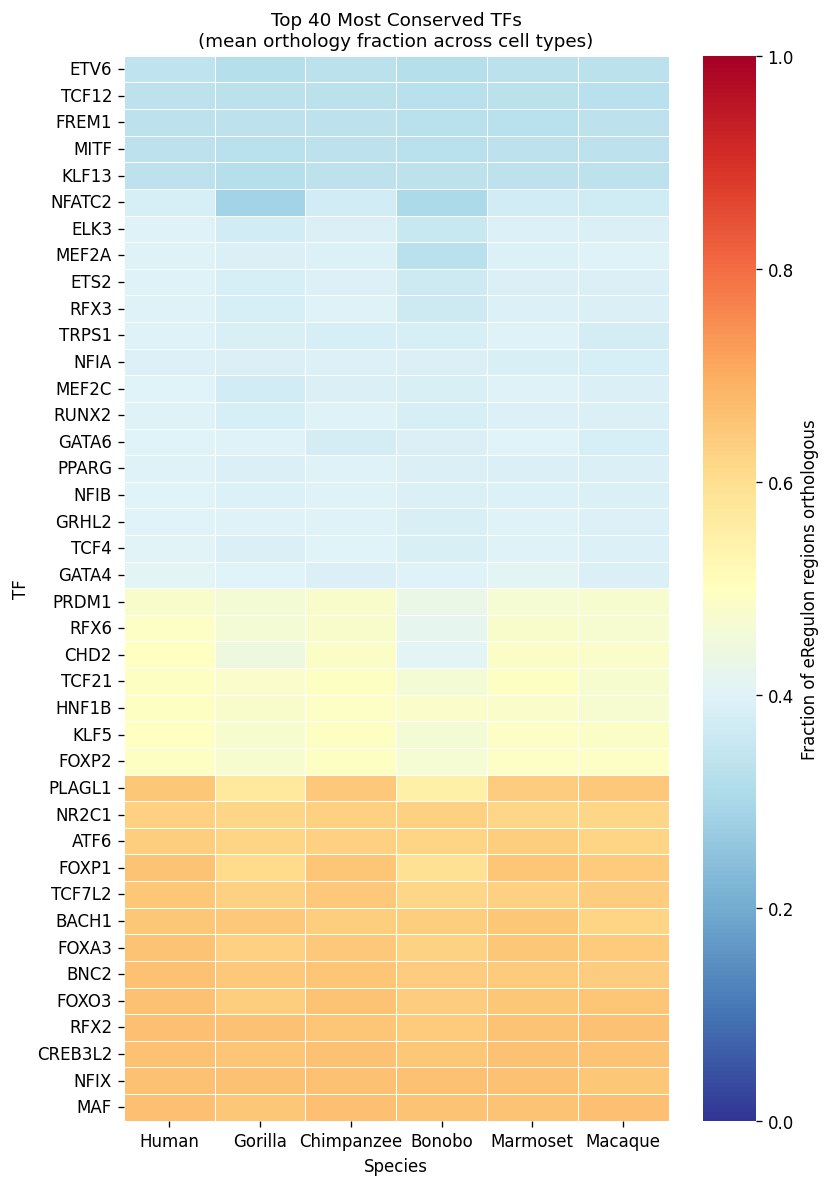

In [21]:
# ── Fig 3: Heatmap – top 40 most conserved TFs ──
top40_cons = tf_global.nlargest(40, "orth_mean_mean").set_index("TF")
heat2 = top40_cons[frac_orth_cols].rename(columns=lambda c: c.replace("frac_orth_", ""))
heat2 = heat2.loc[heat2.mean(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(7, 10))
sns.heatmap(heat2, cmap="RdYlBu_r", vmin=0, vmax=1, linewidths=0.3,
            linecolor="white", cbar_kws={"label": "Fraction of eRegulon regions orthologous"},
            ax=ax)
ax.set_title("Top 40 Most Conserved TFs\n(mean orthology fraction across cell types)", fontsize=11)
ax.set_xlabel("Species")
ax.set_ylabel("TF")
# Color species column labels
for lbl in ax.get_xticklabels():
    lbl.set_color(SPECIES_COLORS.get(lbl.get_text(), "black"))
plt.tight_layout()
plt.savefig(OUT_DIR / "Fig3_heatmap_top40_conserved_TFs.pdf", bbox_inches="tight")
plt.savefig(OUT_DIR / "Fig3_heatmap_top40_conserved_TFs.png", dpi=150, bbox_inches="tight")
plt.show()

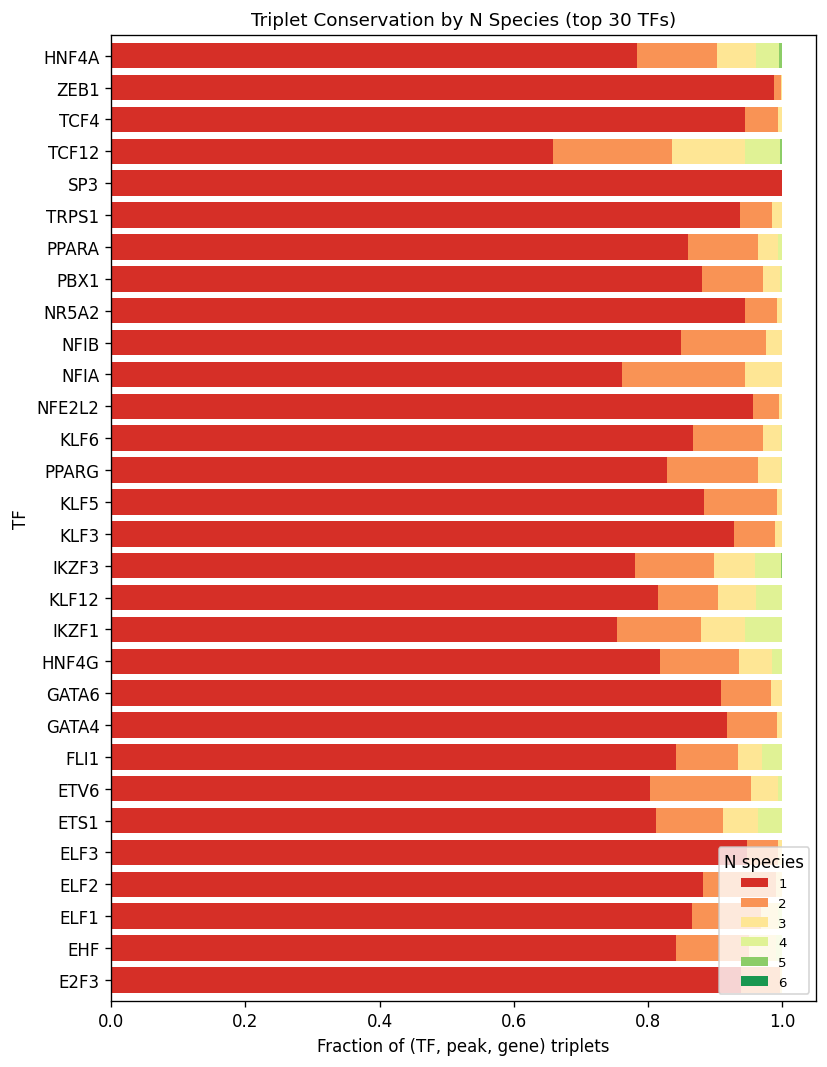

In [22]:
# ── Fig 4: Stacked bar – triplet conservation by N-species, top 30 TFs ──

# Count unique (TF, peak_id, Gene) triplets per number of species with the link
triplet_sp = (
    combined_annot
    .groupby(["TF", "peak_id", "Gene"])["species"]
    .apply(frozenset)
    .reset_index()
    .rename(columns={"species": "species_set"})
)
triplet_sp["n_species"] = triplet_sp["species_set"].apply(len)

top_tfs_by_triplets = (
    triplet_sp.groupby("TF").size()
    .nlargest(30).index.tolist()
)

class_counts = (
    triplet_sp[triplet_sp["TF"].isin(top_tfs_by_triplets)]
    .groupby(["TF", "n_species"]).size()
    .unstack(fill_value=0)
    .reindex(columns=range(1, 7), fill_value=0)
)
class_frac = class_counts.div(class_counts.sum(axis=1), axis=0)
class_frac = class_frac.sort_values(6, ascending=True)

# Conservation gradient: 1 species (lightest) → 6 species (human green)
import matplotlib.colors as mcolors
conservation_cmap = mcolors.LinearSegmentedColormap.from_list(
    "conservation", ["#d9d9d9", "#a1d99b", "#41ab5d", SPECIES_COLORS["Human"]], N=256
)
colors = conservation_cmap(np.linspace(0.05, 0.95, 6))
fig, ax = plt.subplots(figsize=(7, 9))
class_frac.plot(kind="barh", stacked=True, ax=ax, color=colors, width=0.8)
ax.set_xlabel("Fraction of (TF, peak, gene) triplets", fontsize=10)
ax.set_title("Triplet Conservation by N Species (top 30 TFs)", fontsize=11)
ax.legend(title="N species", loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / "Fig4_triplet_conservation_stacked.pdf", bbox_inches="tight")
plt.savefig(OUT_DIR / "Fig4_triplet_conservation_stacked.png", dpi=150, bbox_inches="tight")
plt.show()

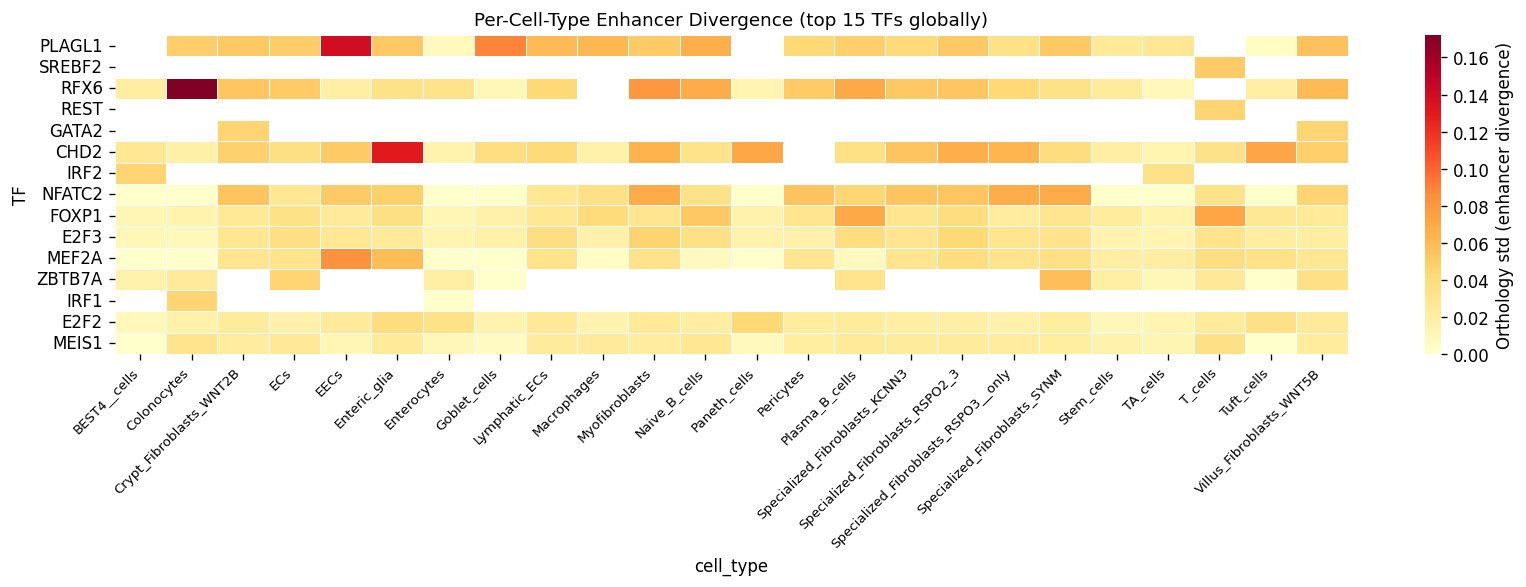

In [23]:
# ── Fig 5: Per-cell-type divergence for selected TFs ──
# For a set of biologically interesting TFs, show orth_std across cell types

# Pick top 15 globally diverged TFs
selected_tfs = tf_global.nlargest(15, "orth_std_mean")["TF"].tolist()

ct_heat = (
    tf_div_filt[tf_div_filt["TF"].isin(selected_tfs)]
    .pivot_table(index="TF", columns="cell_type", values="orth_std", aggfunc="mean")
)
# Order TFs by mean
ct_heat = ct_heat.loc[ct_heat.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(ct_heat, cmap="YlOrRd", vmin=0, linewidths=0.3,
            cbar_kws={"label": "Orthology std (enhancer divergence)"}, ax=ax)
ax.set_title("Per-Cell-Type Enhancer Divergence (top 15 TFs globally)", fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
# Color cell-type column labels
for lbl in ax.get_xticklabels():
    lbl.set_color(CT_COLOR_LOOKUP.get(lbl.get_text(), "black"))
plt.tight_layout()
plt.savefig(OUT_DIR / "Fig5_per_celltype_divergence_heatmap.pdf", bbox_inches="tight")
plt.savefig(OUT_DIR / "Fig5_per_celltype_divergence_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Human-specific eRegulon links

In [24]:
nhp_orth_cols = [c for c in orth_cols if not c.startswith("Human")]

human_df = combined_annot[combined_annot["species"] == "Human"].copy()
human_df["n_nhp_orth"] = human_df[nhp_orth_cols].fillna(0).sum(axis=1)

hs_links = human_df[human_df["n_nhp_orth"] == 0].copy()

print(f"Human eRegulon triplets (all cell types): {len(human_df):,}")
print(f"Human-specific (no NHP ortholog):         {len(hs_links):,} ({100*len(hs_links)/len(human_df):.1f}%)")
print()
print("Top TFs with most human-specific links (across cell types):")
print(
    hs_links.groupby(["TF","cell_type"]).size()
    .reset_index(name="n_hs_links")
    .sort_values("n_hs_links", ascending=False)
    .head(20)
    .to_string(index=False)
)

out = OUT_DIR / "human_specific_eregulon_links_by_celltype.tsv"
hs_links.to_csv(out, sep="\t", index=False)
print(f"\nSaved: {out}")

Human eRegulon triplets (all cell types): 273,487
Human-specific (no NHP ortholog):         184 (0.1%)

Top TFs with most human-specific links (across cell types):
   TF                     cell_type  n_hs_links
PPARA                  Goblet_cells           5
PPARA                   Enterocytes           5
PPARA                   Colonocytes           5
HNF4A                   Colonocytes           4
HNF4A                   Enterocytes           4
HNF4A                  Goblet_cells           4
 KLF5  Specialized_Fibroblasts_SYNM           4
 KLF5       Crypt_Fibroblasts_WNT2B           4
 KLF5 Specialized_Fibroblasts_KCNN3           4
 KLF5                     Pericytes           4
 KLF5                  Enteric_glia           4
 KLF5                 Lymphatic_ECs           4
 FLI1                Plasma_B_cells           3
 FLI1                       T_cells           3
 KLF5                           ECs           3
 KLF5                   Macrophages           3
 KLF5      Villus_Fi

## 10. Summary

In [25]:
print("=" * 60)
print("ANALYSIS SUMMARY")
print("=" * 60)
print(f"Species:               {list(eregulon_raw.keys())}")
print(f"Common cell types:     {len(COMMON_CELL_TYPES)}")
print(f"Total stratified rows: {len(combined_annot):,}")
print(f"Unique TFs:            {combined_annot['TF'].nunique()}")
print(f"Unique peak_ids:       {combined_annot['peak_id'].nunique():,}")
print()
print(f"(TF, cell_type) pairs (after filtering): {len(tf_div_filt):,}")
print()
print("Top 10 most diverged TFs (enhancer level, across cell types):")
print(tf_global.nlargest(10, "orth_std_mean")[["TF", "n_cell_types", "orth_mean_mean", "orth_std_mean"]].to_string(index=False))
print()
print("Top 10 most diverged TFs (target gene level):")
print(tf_global.nsmallest(10, "gene_jaccard_mean")[["TF", "n_cell_types", "gene_jaccard_mean"]].to_string(index=False))
print()
print(f"Outputs saved to: {OUT_DIR}")

ANALYSIS SUMMARY
Species:               ['Human', 'Gorilla', 'Chimpanzee', 'Bonobo', 'Marmoset', 'Macaque']
Common cell types:     24
Total stratified rows: 1,586,762
Unique TFs:            229
Unique peak_ids:       35,370

(TF, cell_type) pairs (after filtering): 1,739

Top 10 most diverged TFs (enhancer level, across cell types):
    TF  n_cell_types  orth_mean_mean  orth_std_mean
SREBF2           1.0        0.301932       0.050552
PLAGL1          21.0        0.616552       0.048523
 GATA2           2.0        0.314815       0.045361
  REST           1.0        0.314815       0.045361
NFATC2          24.0        0.347438       0.041947
  IRF2           2.0        0.317340       0.039175
  CHD2          23.0        0.468401       0.038590
  RFX6          22.0        0.466763       0.031137
 MEF2A          24.0        0.382834       0.028936
 FOXP1          24.0        0.634893       0.028416

Top 10 most diverged TFs (target gene level):
   TF  n_cell_types  gene_jaccard_mean
BACH1  